# Robustez e agregação anual da tendência de duração

Este notebook complementa a inferência principal avaliando dois pontos metodológicos:

- filmes do mesmo ano podem compartilhar contexto histórico e industrial, então uma agregação anual evita que anos com mais indicados tenham mais peso no ajuste;
- filmes muito longos ou muito curtos podem influenciar a reta OLS, então uma regressão robusta ajuda a avaliar sensibilidade a outliers.

O objetivo é verificar se a conclusão de aumento da duração permanece coerente sob especificações alternativas.

## 1. Configuração

A análise usa `statsmodels` para OLS, regressão robusta e estimação com erros padrão robustos por cluster anual.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrix
from statsmodels.stats.weightstats import DescrStatsW

In [2]:
sns.set_theme(context="notebook", style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (18, 8)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)

In [3]:
def find_project_dir() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "data" / "gold").exists() and candidate.name == "cinematic_chronos":
            return candidate
        nested = candidate / "cinematic_chronos"
        if (nested / "data" / "gold").exists():
            return nested
    raise FileNotFoundError(
        "Não foi possível localizar cinematic_chronos/data/gold.")

In [4]:
PROJECT_DIR = find_project_dir()
GOLD_PATH = PROJECT_DIR / "data" / "gold" / \
    "oscar_best_picture_nominees_runtime.parquet"
ALPHA = 0.05
GOLD_PATH

WindowsPath('c:/WorkspaceHub/SourceHub/data-scientist/cinematic_chronos/data/gold/oscar_best_picture_nominees_runtime.parquet')

## 2. Base analítica

Partimos da mesma camada `gold` usada no notebook inferencial principal.

In [5]:
df = pd.read_parquet(GOLD_PATH)
model_data = df[["film", "year_film",
                 "runtime_minutes", "winner"]].dropna().copy()
model_data["year_film"] = model_data["year_film"].astype(int)
model_data["runtime_minutes"] = model_data["runtime_minutes"].astype(float)
model_data["decade"] = ((model_data["year_film"] // 10) * 10).astype(int)
model_data["year_centered"] = model_data["year_film"] - \
    model_data["year_film"].mean()
model_data["winner_label"] = np.where(
    model_data["winner"], "Vencedor", "Indicado")

print(f"Observações: {len(model_data):,}")
print(
    f"Período: {model_data['year_film'].min()}-{model_data['year_film'].max()}")
model_data.head()

Observações: 621
Período: 1927-2025


,film,year_film,runtime_minutes,winner,decade,year_centered,winner_label
0,The Racket,1927,88.0000,False,1920,-50.3591,Indicado
1,7th Heaven,1927,119.0000,False,1920,-50.3591,Indicado
2,Wings,1927,144.0000,True,1920,-50.3591,Vencedor
3,Alibi,1928,90.0000,False,1920,-49.3591,Indicado
4,In Old Arizona,1928,95.0000,False,1920,-49.3591,Indicado


## 3. Modelo base em nível de filme

Este é o modelo de referência: cada filme indicado recebe o mesmo peso.

In [6]:
X_film = sm.add_constant(model_data["year_film"])
y_film = model_data["runtime_minutes"]
ols_film = sm.OLS(y_film, X_film).fit()
ols_film_hc3 = ols_film.get_robustcov_results(cov_type="HC3")
ols_film_cluster_year = ols_film.get_robustcov_results(
    cov_type="cluster",
    groups=model_data["year_film"],
)

base_result = pd.DataFrame(
    {
        "métrica": ["beta_1", "p_value clássico", "p_value HC3", "p_value cluster por ano", "R²"],
        "valor": [
            ols_film.params["year_film"],
            ols_film.pvalues["year_film"],
            pd.Series(ols_film_hc3.pvalues, index=ols_film.params.index)[
                "year_film"],
            pd.Series(ols_film_cluster_year.pvalues,
                      index=ols_film.params.index)["year_film"],
            ols_film.rsquared,
        ],
    }
)
base_result

,métrica,valor
0,beta_1,0.2402
1,p_value clássico,0.0000
2,p_value HC3,0.0000
3,p_value cluster por ano,0.0000
4,R²,0.0741


## 4. Agregação anual

Nesta especificação, cada ano vira uma observação com a duração média e mediana dos indicados daquele ano. Isso reduz a dependência entre filmes do mesmo ano e evita que anos com mais indicados dominem o ajuste.

In [7]:
yearly = (
    model_data.groupby("year_film", as_index=False)
    .agg(
        runtime_mean=("runtime_minutes", "mean"),
        runtime_median=("runtime_minutes", "median"),
        runtime_std=("runtime_minutes", "std"),
        nominees=("film", "count"),
    )
)

yearly["runtime_std"] = yearly["runtime_std"].fillna(0)
yearly.head()

,year_film,runtime_mean,runtime_median,runtime_std,nominees
0,1927,117.0000,119.0000,28.0535,3
1,1928,103.4000,101.0000,11.8448,5
2,1929,105.8000,95.0000,24.0562,5
3,1930,96.2000,101.0000,9.3113,5
4,1931,89.3750,89.0000,8.4842,8


In [8]:
X_year = sm.add_constant(yearly["year_film"])
ols_year_mean = sm.OLS(yearly["runtime_mean"], X_year).fit()
ols_year_median = sm.OLS(yearly["runtime_median"], X_year).fit()

# WLS opcional: anos com mais indicados têm estimativa média mais estável, mas isso reintroduz ponderação por quantidade de filmes.
wls_year_mean = sm.WLS(
    yearly["runtime_mean"],
    X_year,
    weights=yearly["nominees"],
).fit()

annual_results = pd.DataFrame(
    [
        {
            "modelo": "OLS filme individual",
            "alvo": "runtime_minutes",
            "peso": "1 por filme",
            "beta_1": ols_film.params["year_film"],
            "p_value": ols_film.pvalues["year_film"],
            "r_squared": ols_film.rsquared,
            "n_obs": int(ols_film.nobs),
        },
        {
            "modelo": "OLS média anual",
            "alvo": "runtime_mean",
            "peso": "1 por ano",
            "beta_1": ols_year_mean.params["year_film"],
            "p_value": ols_year_mean.pvalues["year_film"],
            "r_squared": ols_year_mean.rsquared,
            "n_obs": int(ols_year_mean.nobs),
        },
        {
            "modelo": "OLS mediana anual",
            "alvo": "runtime_median",
            "peso": "1 por ano",
            "beta_1": ols_year_median.params["year_film"],
            "p_value": ols_year_median.pvalues["year_film"],
            "r_squared": ols_year_median.rsquared,
            "n_obs": int(ols_year_median.nobs),
        },
        {
            "modelo": "WLS média anual",
            "alvo": "runtime_mean",
            "peso": "número de indicados no ano",
            "beta_1": wls_year_mean.params["year_film"],
            "p_value": wls_year_mean.pvalues["year_film"],
            "r_squared": wls_year_mean.rsquared,
            "n_obs": int(wls_year_mean.nobs),
        },
    ]
)
annual_results

,modelo,alvo,peso,beta_1,p_value,r_squared,n_obs
0,OLS filme individual,runtime_minutes,1 por filme,0.2402,0.0000,0.0741,621
1,OLS média anual,runtime_mean,1 por ano,0.2198,0.0001,0.1514,98
2,OLS mediana anual,runtime_median,1 por ano,0.2133,0.0002,0.1323,98
3,WLS média anual,runtime_mean,número de indicados no ano,0.2402,0.0000,0.2171,98


In [9]:
year_grid = pd.DataFrame({"year_film": np.arange(
    yearly["year_film"].min(), yearly["year_film"].max() + 1)})
year_grid_const = sm.add_constant(year_grid)

pred_film = ols_film.get_prediction(year_grid_const).summary_frame(alpha=ALPHA)
pred_mean = ols_year_mean.get_prediction(
    year_grid_const).summary_frame(alpha=ALPHA)
pred_median = ols_year_median.get_prediction(
    year_grid_const).summary_frame(alpha=ALPHA)

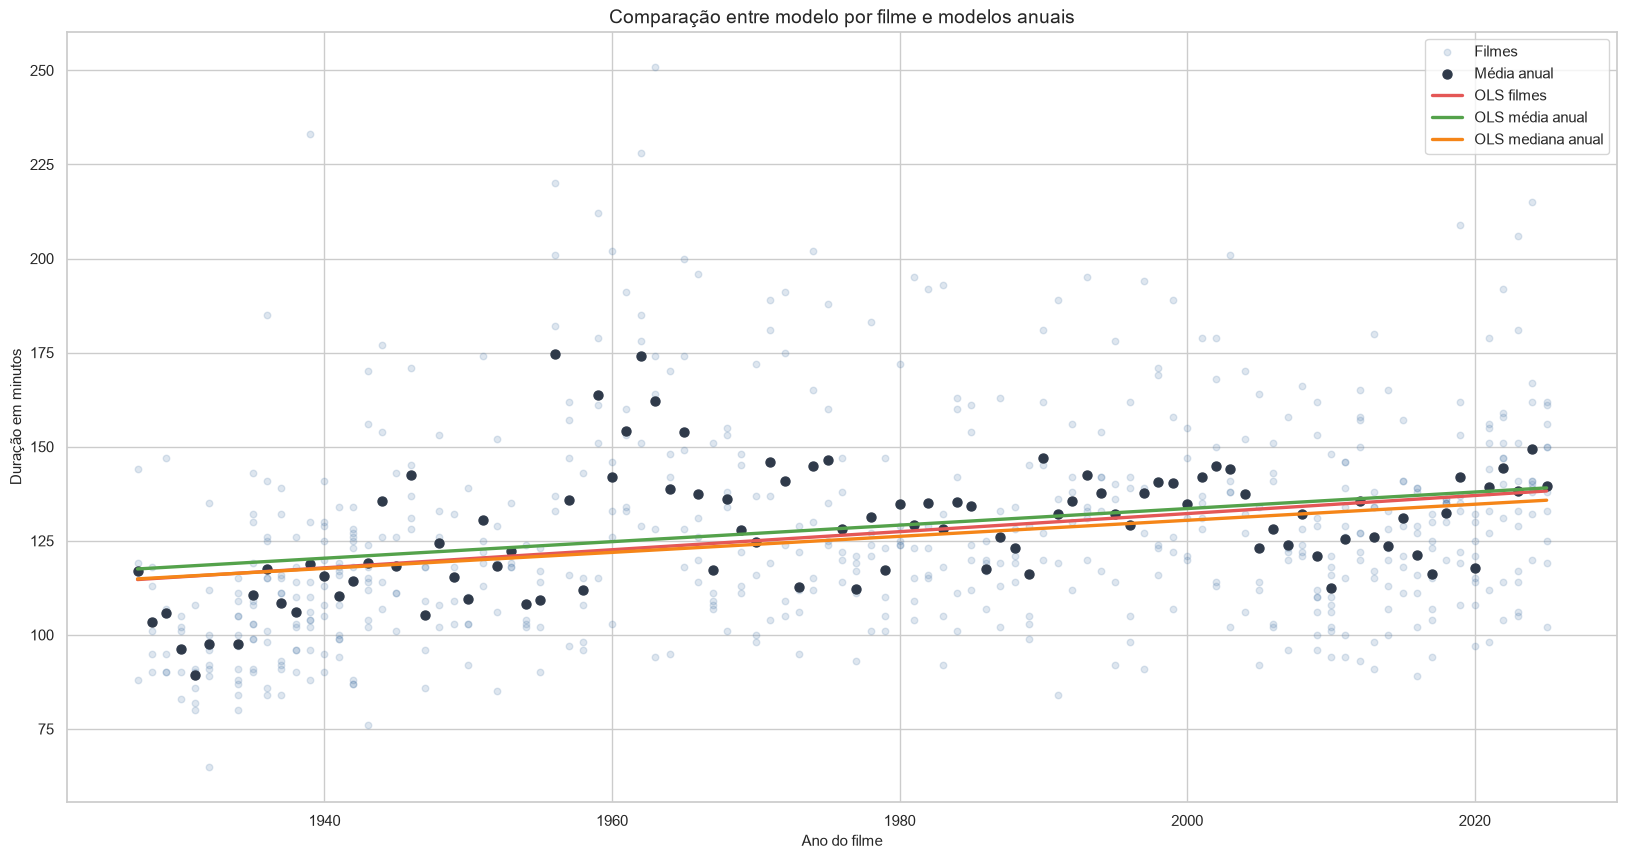

In [10]:
fig, ax = plt.subplots(figsize=(20, 10))
ax.scatter(model_data["year_film"], model_data["runtime_minutes"],
           alpha=0.18, s=22, color="#4C78A8", label="Filmes")
ax.scatter(yearly["year_film"], yearly["runtime_mean"],
           s=42, color="#2F3A4A", label="Média anual")
ax.plot(year_grid["year_film"], pred_film["mean"],
        color="#E45756", linewidth=2.4, label="OLS filmes")
ax.plot(year_grid["year_film"], pred_mean["mean"],
        color="#54A24B", linewidth=2.4, label="OLS média anual")
ax.plot(year_grid["year_film"], pred_median["mean"],
        color="#F58518", linewidth=2.4, label="OLS mediana anual")
ax.set_title("Comparação entre modelo por filme e modelos anuais")
ax.set_xlabel("Ano do filme")
ax.set_ylabel("Duração em minutos")
ax.legend()
plt.show()

## 5. Regressão robusta a outliers

A regressão robusta (`RLM`) reduz a influência de observações extremas. Ela não resolve dependência temporal, mas ajuda a verificar se filmes muito longos ou muito curtos são responsáveis pelo sinal positivo.

In [11]:
rlm_huber = sm.RLM(
    y_film,
    X_film,
    M=sm.robust.norms.HuberT(),
).fit()
rlm_tukey = sm.RLM(
    y_film,
    X_film,
    M=sm.robust.norms.TukeyBiweight(),
).fit()

robust_results = pd.DataFrame(
    [
        {
            "modelo": "OLS filme individual",
            "beta_1": ols_film.params["year_film"],
            "p_value": ols_film.pvalues["year_film"],
            "observação": "referência clássica",
        },
        {
            "modelo": "RLM Huber",
            "beta_1": rlm_huber.params["year_film"],
            "p_value": rlm_huber.pvalues["year_film"],
            "observação": "reduz influência de outliers moderados",
        },
        {
            "modelo": "RLM Tukey",
            "beta_1": rlm_tukey.params["year_film"],
            "p_value": rlm_tukey.pvalues["year_film"],
            "observação": "reduz fortemente influência de outliers extremos",
        },
    ]
)
robust_results

,modelo,beta_1,p_value,observação
0,OLS filme individual,0.2402,0.0000,referência clássica
1,RLM Huber,0.2617,0.0000,reduz influência de outliers moderados
2,RLM Tukey,0.2665,0.0000,reduz fortemente influência de outliers extremos


In [12]:
rlm_pred = pd.DataFrame(
    {
        "year_film": year_grid["year_film"],
        "ols": ols_film.predict(year_grid_const),
        "huber": rlm_huber.predict(year_grid_const),
        "tukey": rlm_tukey.predict(year_grid_const),
    }
)

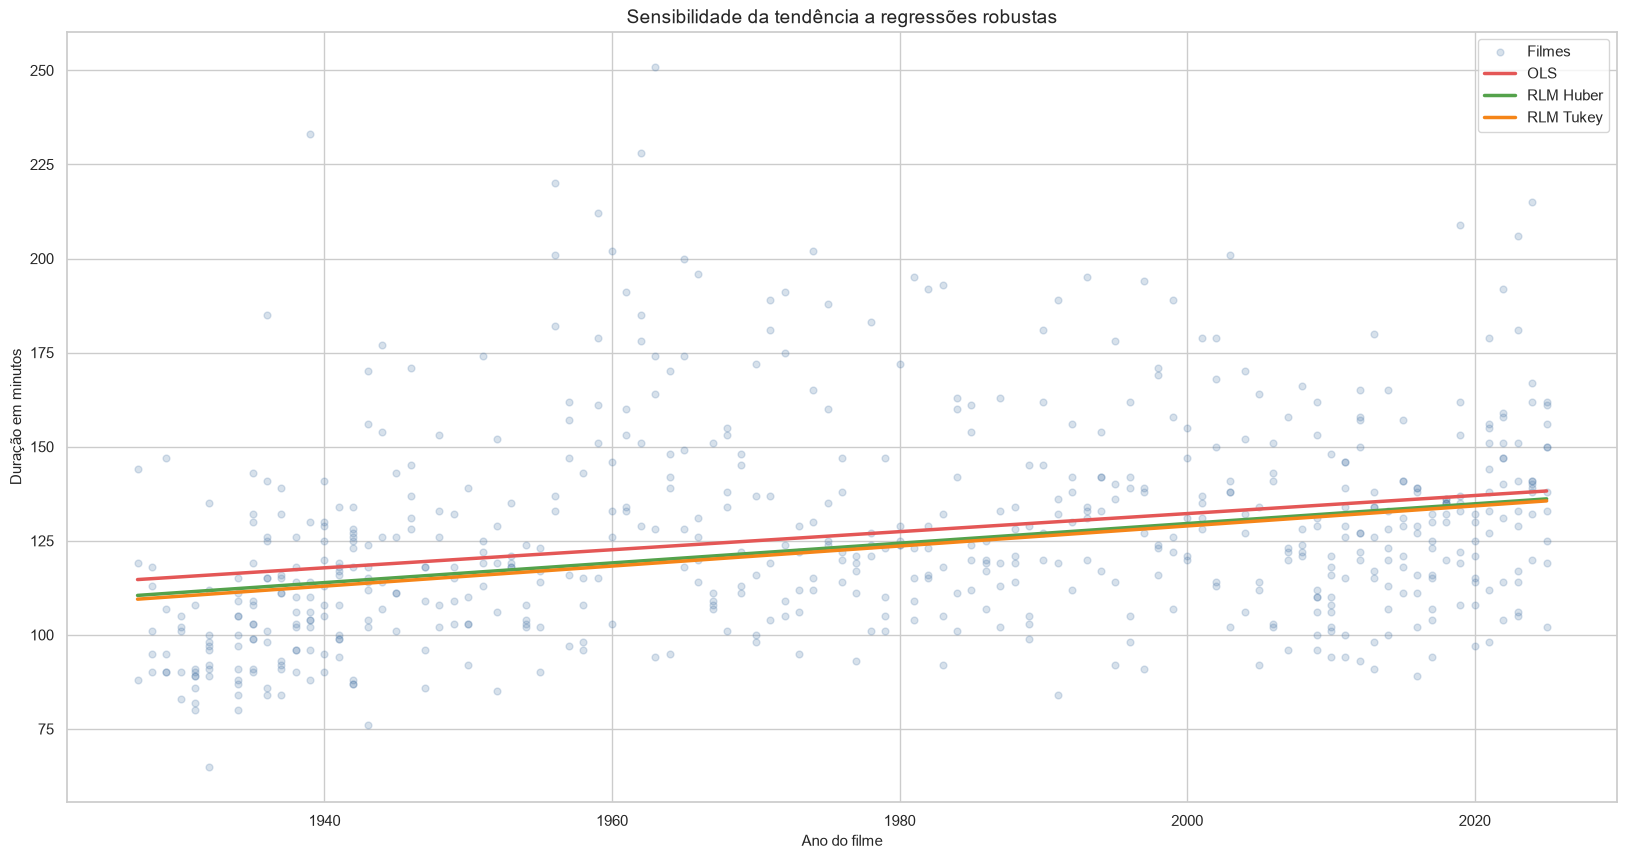

In [13]:
fig, ax = plt.subplots(figsize=(20, 10))
ax.scatter(model_data["year_film"], model_data["runtime_minutes"],
           alpha=0.22, s=24, color="#4C78A8", label="Filmes")
ax.plot(rlm_pred["year_film"], rlm_pred["ols"],
        color="#E45756", linewidth=2.5, label="OLS")
ax.plot(rlm_pred["year_film"], rlm_pred["huber"],
        color="#54A24B", linewidth=2.5, label="RLM Huber")
ax.plot(rlm_pred["year_film"], rlm_pred["tukey"],
        color="#F58518", linewidth=2.5, label="RLM Tukey")
ax.set_title("Sensibilidade da tendência a regressões robustas")
ax.set_xlabel("Ano do filme")
ax.set_ylabel("Duração em minutos")
ax.legend()
plt.show()

## 6. Influência de observações extremas

O gráfico de Cook's distance identifica observações que podem exercer influência elevada no ajuste OLS. Pontos influentes não são automaticamente erros; eles indicam filmes que merecem inspeção.

In [14]:
influence = ols_film.get_influence()
model_data_influence = model_data.copy()
model_data_influence["cooks_distance"] = influence.cooks_distance[0]
model_data_influence["leverage"] = influence.hat_matrix_diag
model_data_influence["studentized_residual"] = influence.resid_studentized_internal

top_influence = model_data_influence.nlargest(12, "cooks_distance")[[
    "year_film", "film", "runtime_minutes", "winner", "cooks_distance", "leverage", "studentized_residual"
]]
top_influence

,year_film,film,runtime_minutes,winner,cooks_distance,leverage,studentized_residual
91,1939,Gone with the Wind,233.0000,True,0.0385,0.0040,4.3584
236,1963,Cleopatra,251.0000,False,0.0227,0.0020,4.8153
602,2024,The Brutalist,215.0000,False,0.0222,0.0052,2.9095
595,2023,Killers of the Flower Moon,206.0000,False,0.0169,0.0051,2.5784
555,2019,The Irishman,209.0000,False,0.0167,0.0045,2.7272
204,1956,The Ten Commandments,220.0000,False,0.0163,0.0024,3.7102
230,1962,Lawrence of Arabia,228.0000,True,0.0157,0.0020,3.9569
62,1936,The Great Ziegfeld,185.0000,True,0.0148,0.0044,2.5736
216,1959,Ben-Hur,212.0000,True,0.0124,0.0022,3.3809
202,1956,Giant,201.0000,False,0.0106,0.0024,2.9934


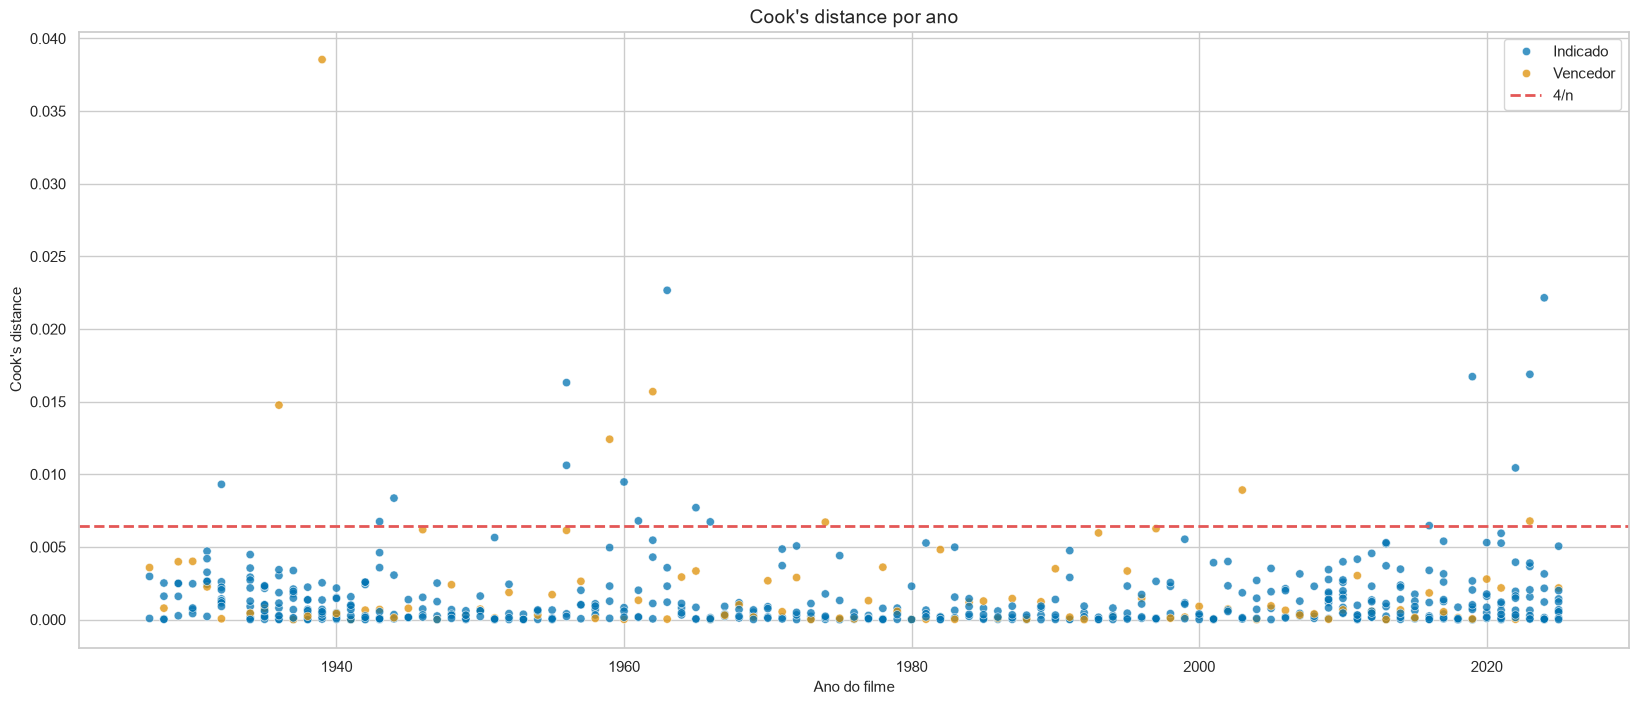

In [15]:
fig, ax = plt.subplots(figsize=(20, 8))
sns.scatterplot(
    data=model_data_influence,
    x="year_film",
    y="cooks_distance",
    hue="winner_label",
    alpha=0.75,
    ax=ax,
)
threshold = 4 / len(model_data_influence)
ax.axhline(threshold, color="#E45756",
           linestyle="--", linewidth=2, label="4/n")
ax.set_title("Cook's distance por ano")
ax.set_xlabel("Ano do filme")
ax.set_ylabel("Cook's distance")
ax.legend()
plt.show()

## 7. Síntese de robustez

A tabela consolida as especificações alternativas. A conclusão é mais confiável quando o sinal de `beta_1` permanece positivo e o p-valor continua abaixo de `alpha` em múltiplas estratégias.

In [16]:
combined = pd.concat(
    [
        annual_results[["modelo", "beta_1", "p_value", "n_obs"]].assign(
            familia="agregação"),
        robust_results[["modelo", "beta_1", "p_value"]].assign(
            n_obs=len(model_data), familia="robusta"),
    ],
    ignore_index=True,
)
combined["significativo_alpha_0_05"] = combined["p_value"] < ALPHA
combined["sinal"] = np.where(combined["beta_1"] > 0, "positivo", "negativo")
combined.sort_values(["familia", "modelo"])

,modelo,beta_1,p_value,n_obs,familia,significativo_alpha_0_05,sinal
0,OLS filme individual,0.2402,0.0000,621,agregação,True,positivo
2,OLS mediana anual,0.2133,0.0002,98,agregação,True,positivo
1,OLS média anual,0.2198,0.0001,98,agregação,True,positivo
3,WLS média anual,0.2402,0.0000,98,agregação,True,positivo
4,OLS filme individual,0.2402,0.0000,621,robusta,True,positivo
5,RLM Huber,0.2617,0.0000,621,robusta,True,positivo
6,RLM Tukey,0.2665,0.0000,621,robusta,True,positivo


In [17]:
all_positive = (combined["beta_1"] > 0).all()
all_significant = (combined["p_value"] < ALPHA).all()

print("Síntese")
print("-" * 8)
print(f"Todas as especificações têm beta_1 positivo? {all_positive}")
print(f"Todas as especificações têm p-valor < {ALPHA}? {all_significant}")
print()
print(
    "Interpretação: se as especificações alternativas mantêm coeficiente positivo "
    "e estatisticamente significativo, a conclusão de aumento da duração é menos "
    "dependente da escolha do modelo linear simples em nível de filme."
)

Síntese
--------
Todas as especificações têm beta_1 positivo? True
Todas as especificações têm p-valor < 0.05? True

Interpretação: se as especificações alternativas mantêm coeficiente positivo e estatisticamente significativo, a conclusão de aumento da duração é menos dependente da escolha do modelo linear simples em nível de filme.


## 8. Limitações

- A agregação anual reduz dependência entre filmes do mesmo ano, mas perde variação entre filmes.
- A regressão robusta reduz influência de outliers, mas não transforma a proxy em uma amostra representativa de todo o cinema.
- Erros padrão clusterizados por ano ajudam na inferência, mas não substituem um desenho causal.
- Resultados consistentes entre especificações devem ser lidos como robustez empírica, não como prova causal.